# Compare DE calculations by MS Stats (R Package) and Auto-Prot



In [1]:
# import necessary libraries
import os
import numpy as np
import pandas as pd

# this allows the notebook to run where ever the repo is located
# set repo_root to two levels up from current working directory
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
print(f"Repo root: {repo_root}")


Repo root: c:\Projects\inProgress\OneDrive_Exile\Auto-prot-validation\MSstats\Auto-Prot


```markdown
# Introduction

This notebook compares differential expression (DE) calculations across three methods: Auto-Prot, Limma (in R) and MS Stats (also an R package). Auto-Prot processes the data using python libraries then calculates DE using Limma. The Limma results here are generated by processing the data in R and estimating DE in R with Limma. MS stats is a separate R package. The R calculations are done by script `autoprot/r_scripts/DE-with-MSstats-Limma.R`. See `docs/compare-DE-methods.md` for info on generating the results that are used in this notebook.

The aims are:
- confirm Auto-Prot performs as expected. This first means generating outputs that are similar to those generated by Limma when used in an R script. Using the same data, do we get similar LFCs and p-values?
- explore impact of imputing on DE results. After confirming Auto-Prot and Limma-in-R produce similar results for the same inputs, compare the outputs of proteins with and without imputation.
- demonstrate impact of using different DE calculations. Compare Auto-Prot output with MS Stats, an R package that uses a different pipeline for processing protein intensities and estimate differential expression.

# Summary

The analysis highlights the following key findings:
- Pairwise comparisons of LFC, raw p-values, and adjusted p-values reveal varying degrees of correlation between the methods.
- Missing data and imputation have a noticeable impact on the results, with imputed values influencing the consistency of DE calculations.
- MSstats appears to apply a stricter correction for adjusted p-values compared to Auto-Prot and Limma, which would have a strong influence on identification of DE genes if using a strict p value cut off

# TLDR
Method choice impacts results - no single method is correct. Best practice involves proper exploration your data, validating results with multiple analyses and ideally experimental validation!

```

In [2]:
### Read in and merge results

# read MSstats results
ms_res_path = os.path.join (repo_root, "output/compare-msstats/MSstats-out.csv")
ms_res = pd.read_csv(ms_res_path)
ms_res['log2FC'] = ms_res['log2FC'] * -1  # invert log2FC to match limma direction

# read Auto-Prot results
ap_res_path = os.path.join (repo_root, "output/full_dataset/data/metast_RDEB/limma_output.csv")
ap_res = pd.read_csv(ap_res_path)

# rename first column of ap_res to "Protein" (to match ms_res)
ap_res = ap_res.rename(columns={ap_res.columns[0]: "Protein"})
ap_res[ 'logFC' ] = ap_res[ 'logFC' ] * -1  # invert log2FC to match limma direction

# read limma results (from R studio)
limma_res_path = os.path.join (repo_root, "output/compare-msstats/Rstudio-limma-out.csv")
limma_res = pd.read_csv(limma_res_path)
# rename first column of ap_res to "Protein" (to match ms_res)
limma_res = limma_res.rename(columns={limma_res.columns[0]: "Protein"})

# proportion missing per protein
prop_missing_path = os.path.join( repo_root, "output/compare-msstats/prop_missing.csv")
prop_missing = pd.read_csv(prop_missing_path)
prop_missing = prop_missing.rename(columns={prop_missing.columns[0]: "Protein"})
prop_missing[ 'proportion_missing'] = round(prop_missing['proportion_missing'], 2)
# if prop missing >0, assign 1, else 0
prop_missing['missing_yes_no'] = np.where(prop_missing['proportion_missing'] > 0, 1, 0)


In [3]:
# how many proteins in MSstats results are also in Auto-Prot results?
# including total number of proteins in each
print(f"Number of proteins in MSstats results: {len(ms_res)}")
print(f"Number of proteins in Auto-Prot results: {len(ap_res)}")
print(f"Number of proteins in Limma results: {len(limma_res)}")
common_proteins = set(ms_res['Protein']).intersection(set(ap_res['Protein'])).intersection(set(limma_res['Protein']))
print(f"Number of common proteins: {len(common_proteins)}")

# print prop missing stats
# % of prots with any missing values
print(f"Percentage of proteins with any missing values: {round((prop_missing['missing_yes_no'].sum() / len(prop_missing)) * 100, 2)}%")
# mean % of prots missing per protein in prots with any missing values
print(f"Mean proportion missing per protein (in proteins with any missing values): {100 * round(prop_missing[prop_missing['missing_yes_no'] == 1]['proportion_missing'].mean(), 2)}%")

### Compare LFC and adjusted p-values for common proteins
# merge results on "Protein" column
merged_res = (
    pd.merge(limma_res, ap_res, on="Protein", suffixes=('_limma', '_ap'))
    .merge(ms_res, on="Protein")
    .merge(prop_missing, on="Protein")
)

merged_res_no_missing = merged_res[ merged_res['proportion_missing'] == 0 ]

Number of proteins in MSstats results: 726
Number of proteins in Auto-Prot results: 726
Number of proteins in Limma results: 726
Number of common proteins: 726
Percentage of proteins with any missing values: 28.1%
Mean proportion missing per protein (in proteins with any missing values): 8.0%


### Comparison of Auto-Prot and Limma Methods

The graphs below illustrate the comparison between the Auto-Prot and Limma (in R) methods. Both methods are applied to proteins with no missing data, ensuring a fair comparison. The key differences between the two methods are:

1. **Normalisation**: Auto-Prot ("vsn" normalisation) and Limma use different normalization techniques, which may influence the results.
2. **Implementation**: Auto-Prot is implemented in Python, while Limma is executed as an R subprocess within the Python environment.

The graphs aim to highlight the similarities and differences in the results produced by these two methods. They provide insights into how the choice of normalization and implementation platform might affect the analysis outcomes. Use these visualizations to assess the consistency and reliability of the two approaches for your dataset.

(0.0, 1.0)

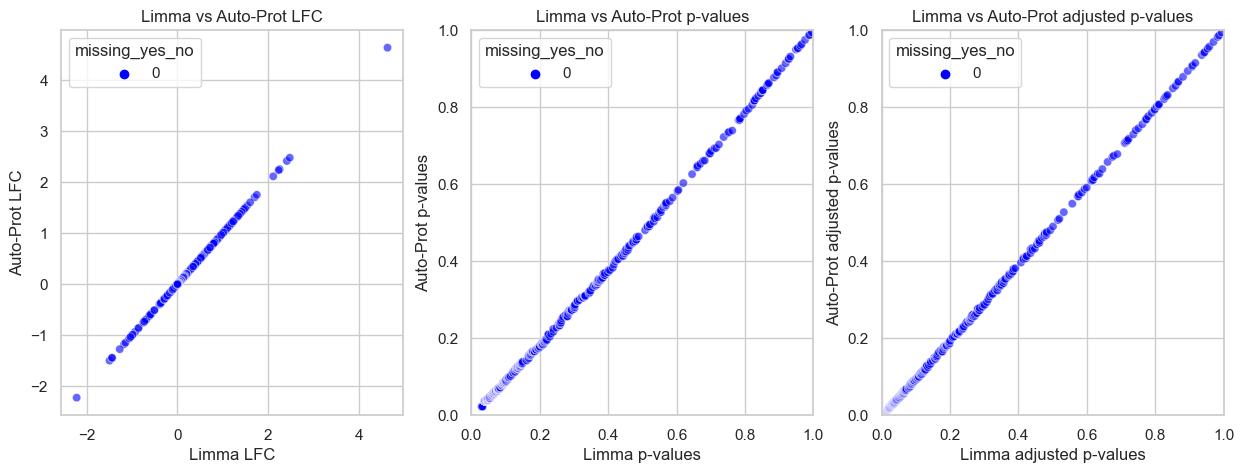

In [4]:
### Compare Limma in R and Auto-prot
# pairwise comparisons of LFC from ap and limma
import matplotlib.pyplot as plt
import seaborn as sns
# set seaborn style
sns.set(style="whitegrid")
# set figure size
plt.figure(figsize=(15, 5))
# set up subplots for one plot
plt.subplot(1, 3, 1)
# compare LFC
sns.scatterplot(data=merged_res_no_missing, x='logFC_limma', y='logFC_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('Limma vs Auto-Prot LFC')
plt.xlabel('Limma LFC')
plt.ylabel('Auto-Prot LFC')
# raw p-values
plt.subplot(1, 3, 2)
sns.scatterplot(data=merged_res_no_missing, x='adj.P.Val_limma', y='adj.P.Val_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('Limma vs Auto-Prot p-values')
plt.xlabel('Limma p-values')
plt.ylabel('Auto-Prot p-values')
plt.xlim(0, 1)
plt.ylim(0, 1)
# adjusted p-values
plt.subplot(1, 3, 3)
sns.scatterplot(data=merged_res_no_missing, x='P.Value_limma', y='P.Value_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('Limma vs Auto-Prot adjusted p-values')
plt.xlabel('Limma adjusted p-values')
plt.ylabel('Auto-Prot adjusted p-values')
plt.xlim(0, 1)
plt.ylim(0, 1)



(0.0, 1.0)

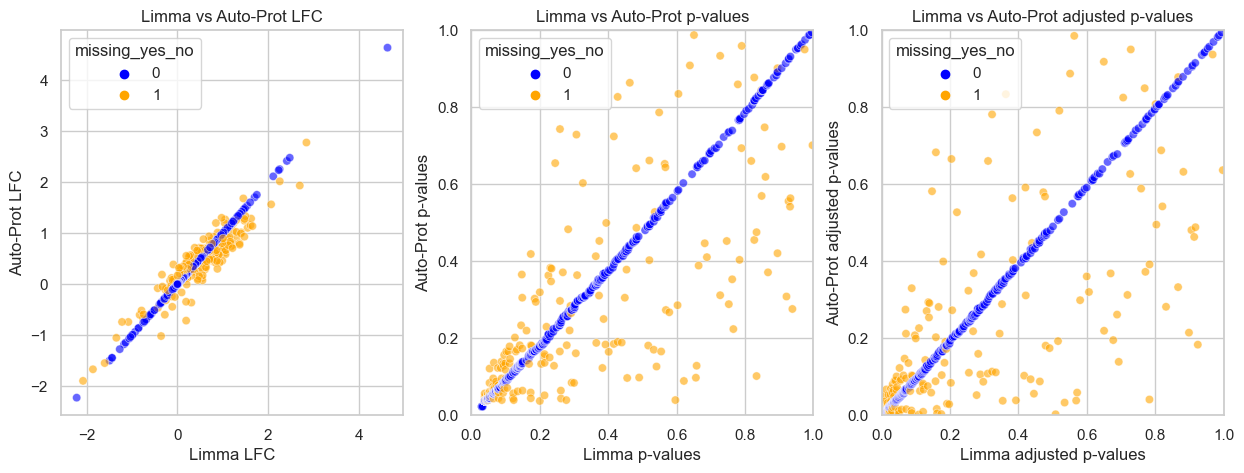

In [25]:
### Compare Limma in R and Auto-prot with imputed values
# pairwise comparisons of LFC from ap and limma
import matplotlib.pyplot as plt
import seaborn as sns
# set seaborn style
sns.set(style="whitegrid")
# set figure size
plt.figure(figsize=(15, 5))
# set up subplots for one plot
plt.subplot(1, 3, 1)
# compare LFC
sns.scatterplot(data=merged_res, x='logFC_limma', y='logFC_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('Limma vs Auto-Prot LFC')
plt.xlabel('Limma LFC')
plt.ylabel('Auto-Prot LFC')
# raw p-values
plt.subplot(1, 3, 2)
sns.scatterplot(data=merged_res, x='adj.P.Val_limma', y='adj.P.Val_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('Limma vs Auto-Prot p-values')
plt.xlabel('Limma p-values')
plt.ylabel('Auto-Prot p-values')
plt.xlim(0, 1)
plt.ylim(0, 1)
# adjusted p-values
plt.subplot(1, 3, 3)
sns.scatterplot(data=merged_res, x='P.Value_limma', y='P.Value_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('Limma vs Auto-Prot adjusted p-values')
plt.xlabel('Limma adjusted p-values')
plt.ylabel('Auto-Prot adjusted p-values')
plt.xlim(0, 1)
plt.ylim(0, 1)



(0.0, 1.0)

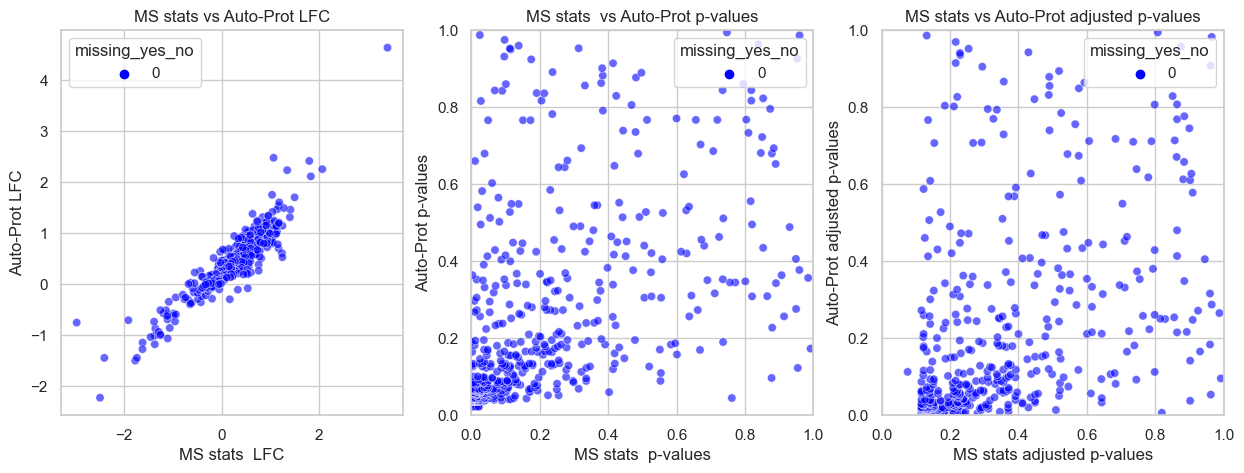

In [29]:
### Compare MS Stats in R and Auto-prot
# pairwise comparisons of LFC from ap and limma
import matplotlib.pyplot as plt
import seaborn as sns
# set seaborn style
sns.set(style="whitegrid")
# set figure size
plt.figure(figsize=(15, 5))
# set up subplots for one plot
plt.subplot(1, 3, 1)
# compare LFC
sns.scatterplot(data=merged_res_no_missing, x='log2FC', y='logFC_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('MS stats vs Auto-Prot LFC')
plt.xlabel('MS stats  LFC')
plt.ylabel('Auto-Prot LFC')
# raw p-values
plt.subplot(1, 3, 2)
sns.scatterplot(data=merged_res_no_missing, x='pvalue', y='adj.P.Val_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('MS stats  vs Auto-Prot p-values')
plt.xlabel('MS stats  p-values')
plt.ylabel('Auto-Prot p-values')
plt.xlim(0, 1)
plt.ylim(0, 1)
# adjusted p-values
plt.subplot(1, 3, 3)
sns.scatterplot(data=merged_res_no_missing, x='adj.pvalue', y='P.Value_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('MS stats vs Auto-Prot adjusted p-values')
plt.xlabel('MS stats adjusted p-values')
plt.ylabel('Auto-Prot adjusted p-values')
plt.xlim(0, 1)
plt.ylim(0, 1)

(0.0, 1.0)

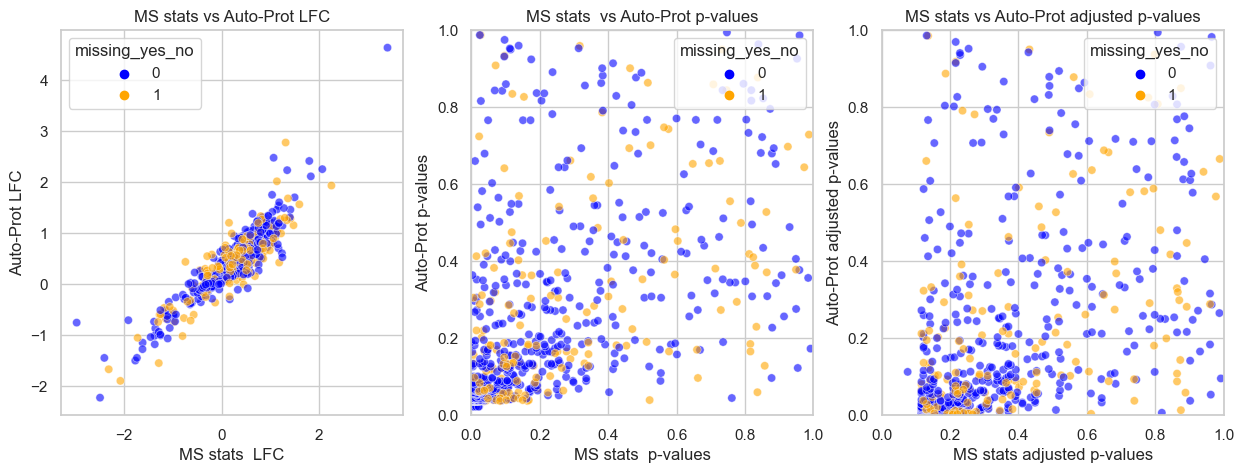

In [30]:
### Compare MS Stats in R and Auto-prot
# pairwise comparisons of LFC from ap and limma
import matplotlib.pyplot as plt
import seaborn as sns
# set seaborn style
sns.set(style="whitegrid")
# set figure size
plt.figure(figsize=(15, 5))
# set up subplots for one plot
plt.subplot(1, 3, 1)
# compare LFC
sns.scatterplot(data=merged_res, x='log2FC', y='logFC_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('MS stats vs Auto-Prot LFC')
plt.xlabel('MS stats  LFC')
plt.ylabel('Auto-Prot LFC')
# raw p-values
plt.subplot(1, 3, 2)
sns.scatterplot(data=merged_res, x='pvalue', y='adj.P.Val_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('MS stats  vs Auto-Prot p-values')
plt.xlabel('MS stats  p-values')
plt.ylabel('Auto-Prot p-values')
plt.xlim(0, 1)
plt.ylim(0, 1)
# adjusted p-values
plt.subplot(1, 3, 3)
sns.scatterplot(data=merged_res, x='adj.pvalue', y='P.Value_ap', hue = 'missing_yes_no', palette={0: 'blue', 1: 'orange'}, alpha=0.6)
plt.title('MS stats vs Auto-Prot adjusted p-values')
plt.xlabel('MS stats adjusted p-values')
plt.ylabel('Auto-Prot adjusted p-values')
plt.xlim(0, 1)
plt.ylim(0, 1)

In [ ]:
# # Limma vs MSstats
# sns.scatterplot(data=merged_res_no_missing, x='logFC_limma', y='log2FC')
# plt.title('Limma vs MSstats LFC')
# plt.xlabel('Limma LFC')
# plt.ylabel('MSstats LFC')
# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
# plt.subplot(1, 3, 3)
# # Auto-Prot vs MSstats
# sns.scatterplot(data=merged_res_no_missing, x='logFC_ap', y='log2FC')
# plt.title('Auto-Prot vs MSstats LFC')
# plt.xlabel('Auto-Prot LFC')
# plt.ylabel('MSstats LFC')
# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
# plt.tight_layout()
# plt.show()
# # save figure
# plt.savefig(os.path.join(repo_root, "output/compare-msstats/lfc_comparison_no_imputed.png"))
# plt.close()

In [ ]:
# ### Compare LFC
# # pairwise comparisons of LFC from all three methods
# # coloured by proportion missing
# import matplotlib.pyplot as plt
# import seaborn as sns
# # set seaborn style
# sns.set(style="whitegrid")
# # set figure size
# plt.figure(figsize=(15, 5))
# # set up subplots
# plt.subplot(1, 3, 1)
# # Limma vs Auto-Prot
# sns.scatterplot(data=merged_res, x='logFC_limma', y='logFC_ap', hue='missing_yes_no', palette='viridis', legend='full')
# # sns.scatterplot(data=merged_res, x='logFC_limma', y='logFC_ap')
# plt.title('Limma vs Auto-Prot LFC')
# plt.xlabel('Limma LFC')
# plt.ylabel('Auto-Prot LFC')
# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
# plt.subplot(1, 3, 2)
# # Limma vs MSstats
# sns.scatterplot(data=merged_res, x='logFC_limma', y='log2FC', hue='missing_yes_no', palette='viridis', legend='full')
# plt.title('Limma vs MSstats LFC')
# plt.xlabel('Limma LFC')
# plt.ylabel('MSstats LFC')
# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
# plt.subplot(1, 3, 3)
# # Auto-Prot vs MSstats
# sns.scatterplot(data=merged_res, x='logFC_ap', y='log2FC', hue='missing_yes_no', palette='viridis', legend='full')
# plt.title('Auto-Prot vs MSstats LFC')
# plt.xlabel('Auto-Prot LFC')
# plt.ylabel('MSstats LFC')
# plt.xlim(-5, 5)
# plt.ylim(-5, 5)
# plt.tight_layout()
# plt.show()
# # save figure
# plt.savefig(os.path.join(repo_root, "output/compare-msstats/lfc_comparison_with_imputed.png"))
# plt.close()


In [ ]:
# ### Compare raw p-values
# # pairwise comparisons of raw p-values from all three methods
# # set figure size
# plt.figure(figsize=(15, 5))
# # set up subplots
# plt.subplot(1, 3, 1)
# # Limma vs Auto-Prot
# sns.scatterplot(data=merged_res_no_missing, x='P.Value_limma', y='P.Value_ap')
# plt.title('Limma vs Auto-Prot raw p-values')
# plt.xlabel('Limma raw p-value')
# plt.ylabel('Auto-Prot raw p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.subplot(1, 3, 2)
# # Limma vs MSstats
# sns.scatterplot(data=merged_res_no_missing, x='P.Value_limma', y='pvalue')
# plt.title('Limma vs MSstats raw p-values')
# plt.xlabel('Limma raw p-value')
# plt.ylabel('MSstats raw p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.subplot(1, 3, 3)
# # Auto-Prot vs MSstats
# sns.scatterplot(data=merged_res_no_missing, x='P.Value_ap', y='pvalue')
# plt.title('Auto-Prot vs MSstats raw p-values')
# plt.xlabel('Auto-Prot raw p-value')
# plt.ylabel('MSstats raw p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.tight_layout()
# plt.show()
# # save figure
# plt.savefig(os.path.join(repo_root, "output/compare-msstats/raw_pvalue_comparison_no_imputed.png"))
# plt.close()



In [ ]:
# ### Compare raw p-values
# # pairwise comparisons of raw p-values from all three methods
# # set figure size
# plt.figure(figsize=(15, 5))
# # set up subplots
# plt.subplot(1, 3, 1)
# # Limma vs Auto-Prot
# sns.scatterplot(data=merged_res, x='P.Value_limma', y='P.Value_ap', hue='missing_yes_no', palette='viridis', legend='full')
# plt.title('Limma vs Auto-Prot raw p-values')
# plt.xlabel('Limma raw p-value')
# plt.ylabel('Auto-Prot raw p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.subplot(1, 3, 2)
# # Limma vs MSstats
# sns.scatterplot(data=merged_res, x='P.Value_limma', y='pvalue', hue='missing_yes_no', palette='viridis', legend='full')
# plt.title('Limma vs MSstats raw p-values')
# plt.xlabel('Limma raw p-value')
# plt.ylabel('MSstats raw p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.subplot(1, 3, 3)
# # Auto-Prot vs MSstats
# sns.scatterplot(data=merged_res, x='P.Value_ap', y='pvalue', hue='missing_yes_no', palette='viridis', legend='full')
# plt.title('Auto-Prot vs MSstats raw p-values')
# plt.xlabel('Auto-Prot raw p-value')
# plt.ylabel('MSstats raw p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.tight_layout()
# plt.show()
# # save figure
# plt.savefig(os.path.join(repo_root, "output/compare-msstats/raw_pvalue_comparison_with_imputed.png"))
# plt.close()



In [ ]:
# ### Compare adjusted p-values
# # pairwise comparisons of adjusted p-values from all three methods
# # set figure size
# plt.figure(figsize=(15, 5))
# # set up subplots
# plt.subplot(1, 3, 1)
# # Limma vs Auto-Prot
# sns.scatterplot(data=merged_res_no_missing, x='adj.P.Val_limma', y='adj.P.Val_ap')
# plt.title('Limma vs Auto-Prot adj p-values')
# plt.xlabel('Limma adj p-value')
# plt.ylabel('Auto-Prot adj p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.subplot(1, 3, 2)
# # Limma vs MSstats
# sns.scatterplot(data=merged_res_no_missing, x='adj.P.Val_limma', y='adj.pvalue')
# plt.title('Limma vs MSstats adj p-values')
# plt.xlabel('Limma adj p-value')
# plt.ylabel('MSstats adj p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.subplot(1, 3, 3)
# # Auto-Prot vs MSstats
# sns.scatterplot(data=merged_res_no_missing, x='adj.P.Val_ap', y='adj.pvalue')
# plt.title('Auto-Prot vs MSstats adj p-values')
# plt.xlabel('Auto-Prot adj p-value')
# plt.ylabel('MSstats adj p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.tight_layout()
# plt.show()
# # save figure
# plt.savefig(os.path.join(repo_root, "output/compare-msstats/adj_pvalue_comparison.png"))
# plt.close()


In [ ]:
# ### Compare adjusted p-values
# # pairwise comparisons of adjusted p-values from all three methods
# # set figure size
# plt.figure(figsize=(15, 5))
# # set up subplots
# plt.subplot(1, 3, 1)
# # Limma vs Auto-Prot
# sns.scatterplot(data=merged_res, x='adj.P.Val_limma', y='adj.P.Val_ap', hue='missing_yes_no', palette='viridis', legend='full')
# plt.title('Limma vs Auto-Prot adj p-values')
# plt.xlabel('Limma adj p-value')
# plt.ylabel('Auto-Prot adj p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.subplot(1, 3, 2)
# # Limma vs MSstats
# sns.scatterplot(data=merged_res, x='adj.P.Val_limma', y='adj.pvalue', hue='missing_yes_no', palette='viridis', legend='full')
# plt.title('Limma vs MSstats adj p-values')
# plt.xlabel('Limma adj p-value')
# plt.ylabel('MSstats adj p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.subplot(1, 3, 3)
# # Auto-Prot vs MSstats
# sns.scatterplot(data=merged_res, x='adj.P.Val_ap', y='adj.pvalue', hue='missing_yes_no', palette='viridis', legend='full')
# plt.title('Auto-Prot vs MSstats adj p-values')
# plt.xlabel('Auto-Prot adj p-value')
# plt.ylabel('MSstats adj p-value')
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.tight_layout()
# plt.show()
# # save figure
# plt.savefig(os.path.join(repo_root, "output/compare-msstats/adj_pvalue_comparison.png"))
# plt.close()


In [22]:
# # calculate correlation between LFC columns MSStats v auto-Prot
# lfc_corr = merged_res['log2FC'].corr(merged_res['logFC_ap'])
# print(f"LFC correlation: {lfc_corr}")

# # use seaborn to plot correlations
# import seaborn as sns
# import matplotlib.pyplot as plt
# sns.set(style="whitegrid")
# # plot LFC correlation
# plt.figure(figsize=(6,6))
# sns.scatterplot(x='log2FC', y='logFC_ap', data=merged_res)
# plt.title(f"LFC Correlation: {lfc_corr:.2f}")
# plt.xlabel("MSstats log2FC")
# plt.ylabel("Auto-Prot logFC")
# # add correlation line including error bars
# sns.regplot(x='log2FC', y='logFC_ap', data=merged_res, scatter=False, color='red')
# plt.savefig(os.path.join(repo_root, "output/compare-msstats/lfc_correlation.png"))
# plt.show()
# plt.close()


In [23]:
# ### Compare adjusted p-values
# # calculate correlation between adjusted p-value columns
# pval_corr = merged_res['adj.pvalue'].corr(merged_res['adj.P.Val'])

# print(f"Adjusted p-value correlation: {pval_corr}")

# # plot adjusted p-value correlation
# plt.figure(figsize=(6,6))
# sns.scatterplot(x='adj.pvalue', y='adj.P.Val', data=merged_res)
# # add correlation line including error bars
# sns.regplot(x='adj.pvalue', y='adj.P.Val', data=merged_res, scatter=False, color='red')
# plt.title(f"Adjusted p-value Correlation: {pval_corr:.2f}")
# # x label title
# plt.xlabel("MSstats adjusted p-value", fontsize=12)
# plt.ylabel("Auto-Prot adjusted p-value", fontsize=12)
# # both axes 0-1
# plt.xlim(0, 1)
# plt.ylim(0, 1)

# plt.savefig(os.path.join(repo_root, "output/compare-msstats/adj_pvalue_correlation.png"))
# plt.show()
# plt.close()

In [24]:
# # Show number of prots with adjusted p-value < 0.05 in each method
# ms_DE = merged_res[merged_res['adj.pvalue'] < 0.05]
# ap_DE = merged_res[merged_res['adj.P.Val'] < 0.05]
# print(f"Number of DE proteins in MSstats: {len(ms_DE)}")
# print(f"Number of DE proteins in Auto-Prot: {len(ap_DE)}")
# # number of common DE proteins
# common_DE = set(ms_DE['Protein']).intersection(set(ap_DE['Protein']))
# print(f"Number of common DE proteins: {len(common_DE)}")
# # list common DE proteins
# print("Common DE proteins:", common_DE)

In [25]:
# ## the correlation in adjusted p values is not as high

# ## plot side by side the correlations of adjusted p-values vs LFC in MS stats and p-values vs LFC in Auto-Prot
# ## plot side by side the correlations of adjusted p-values vs absolute LFC in MS stats and p-values vs LFC in Auto-Prot
# plt.figure(figsize=(12,6))

# # MSstats plot
# plt.subplot(1, 2, 1)
# sns.scatterplot(x=merged_res['log2FC'].abs(), y='adj.pvalue', data=merged_res)
# plt.title("MSstats")
# plt.xlabel("Absolute log2FC")
# plt.ylabel("Adjusted p-value")
# plt.ylim(0, 1)
# sns.regplot(x=merged_res['log2FC'].abs(), y='adj.pvalue', data=merged_res, scatter=False, lowess=True, color='red')

# # Auto-Prot plot
# plt.subplot(1, 2, 2)
# sns.scatterplot(x=merged_res['logFC_ap'].abs(), y='adj.P.Val', data=merged_res)
# plt.title("Auto-Prot")
# plt.xlabel("Absolute logFC_ap")
# plt.ylabel("Adjusted p-value")
# plt.ylim(0, 1)
# sns.regplot(x=merged_res['logFC_ap'].abs(), y='adj.P.Val', data=merged_res, scatter=False, lowess=True, color='red')

# plt.tight_layout()
# # plt.savefig(os.path.join(repo_root, "output/compare-msstats/lfc_vs_adj_pvalue_abs.png"))
# plt.show()
# plt.close()


In [26]:
# ### MSstats correction is harsher
# # look at unadjusted p-values
# pval_corr_unadj = merged_res['pvalue'].corr(merged_res['P.Value'])
# print(f"Unadjusted p-value correlation: {pval_corr_unadj}")
# # plot unadjusted p-value correlation
# plt.figure(figsize=(6,6))
# sns.scatterplot(x='pvalue', y='P.Value', data=merged_res)
# # add correlation line including error bars
# sns.regplot(x='pvalue', y='P.Value', data=merged_res, scatter=False, color='red')
# plt.title(f"Unadjusted p-value Correlation: {pval_corr_unadj:.2f}")
# # x label title
# plt.xlabel("MSstats unadjusted p-value", fontsize=12)
# plt.ylabel("Auto-Prot unadjusted p-value", fontsize=12)
# # both axes 0-1
# plt.xlim(0, 1)
# plt.ylim(0, 1)
# plt.savefig(os.path.join(repo_root, "output/compare-msstats/unadj_pvalue_correlation.png"))
# plt.show()
# plt.close()
# # 
